## Nd RoPE

Adapting https://github.com/limefax/rope-nd for geospatial embeddings and p/q rotations every attention layer

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import torch
from torch import nn
from torch import functional as F

In [5]:
class RoPENd(torch.nn.Module):
    """N-dimensional Rotary Positional Embedding."""
    def __init__(self, shape, base=10000):
        super(RoPENd, self).__init__()

        channel_dims, feature_dim = shape[:-1], shape[-1]
        k_max = feature_dim // (2 * len(channel_dims))

        assert feature_dim % k_max == 0, f'shape[-1] ({feature_dim}) is not divisible by 2 * len(shape[:-1]) ({2 * len(channel_dims)})'

        # tensor of angles to use
        theta_ks = 1 / (base ** (torch.arange(k_max) / k_max))

        # create a stack of angles multiplied by position
        angles = torch.cat([t.unsqueeze(-1) * theta_ks for t in
                            torch.meshgrid([torch.arange(d) for d in channel_dims], indexing='ij')], dim=-1)

        # convert to complex number to allow easy rotation
        rotations = torch.polar(torch.ones_like(angles), angles)

        # store in a buffer so it can be saved in model parameters
        self.register_buffer('rotations', rotations)

    def forward(self, x):
        # convert input into complex numbers to perform rotation
        x = torch.view_as_complex(x.reshape(*x.shape[:-1], -1, 2))
        pe_x = self.rotations * x
        return torch.view_as_real(pe_x).flatten(-2)

In [8]:
# Patchify coords
import pathlib
data_path = pathlib.Path("../data/cloudsat-goes-paired/")
files = sorted(list(data_path.glob("*.nc")))
len(files)

3000

In [71]:
from torch.utils.data import Dataset, DataLoader
from lightning.pytorch import LightningDataModule
class GeoDataset(Dataset):
    def __init__(self, files):
        super().__init__()
        self.files = files
    
    def __len__(self):
        return len(self.files)

    def load_image(self, idx):
        with xr.open_datatree(self.files[idx]) as dt:
            image_input = dt.geo_patch.data.fillna(0)
            image_input = image_input[:3] / 100 # 3 channel input
            # image_input[6:] = image_input[6:] / 140 - 180
            image_input = np.clip(image_input, 0, 1).values.astype(np.float32)

            ds = dt.geo_patch
            if "latitude" in ds.data_vars and "longitude" in ds.data_vars:
                lat_offset = (
                    (ds.latitude.encoding["scale_factor"] + ds.latitude.encoding["add_offset"])*2
                    if ds.latitude.encoding["add_offset"] > 0
                    else 0
                )
                lon_offset = (
                    (ds.longitude.encoding["scale_factor"] + ds.longitude.encoding["add_offset"])*2
                    if ds.longitude.encoding["add_offset"] > 0
                    else 0
                )
                latitudes = (ds.latitude - lat_offset).fillna(ds.latitude.encoding["add_offset"])
                longitudes = (ds.longitude - lon_offset).fillna(ds.longitude.encoding["add_offset"])
                time_epoch = np.full(dt.geo_patch.longitude.shape, (dt.geo_patch.t.values - np.datetime64("1970-01-01T00:00:00"))/ np.timedelta64(1, "D"), dtype=np.float32)
                time_of_day = np.full(dt.geo_patch.longitude.shape, (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[D]")) / np.timedelta64(1, "D"), dtype=np.float32)
            
            coords = np.stack([
                longitudes, 
                latitudes, 
                time_of_day,
                time_epoch,
            ], 0).astype(np.float32)
            
        return image_input, coords
    
    def __getitem__(self, idx):
        return self.load_image(idx)

class GeoDataloader(LightningDataModule):
    def __init__(
        self, 
        batch_size, 
        files, 
        num_workers=0, 
    ):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers

        # Get list of files for each split
        self.train_dataset = GeoDataset(files[:int(len(files)*0.7)])
        self.val_dataset = GeoDataset(files[int(len(files)*0.75):int(len(files)*0.85)])
        self.test_dataset = GeoDataset(files[int(len(files)*0.9):])

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, 
            batch_size=self.batch_size, 
            shuffle=True,
            pin_memory=False, 
            num_workers=self.num_workers, 
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=False, 
            num_workers=self.num_workers, 
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.test_dataset, 
            batch_size=self.batch_size, 
            shuffle=False,
            pin_memory=False, 
            num_workers=self.num_workers, 
        )

In [72]:
dl = GeoDataloader(1, files)

In [73]:
image, coords = next(iter(dl.train_dataloader()))

In [85]:
coords.mean((-2,-1))

tensor([[-4.1597e+01, -1.9941e+01,  6.9161e-01,  1.7857e+04]])

In [106]:
def torch_circmean(x, factor, *args):
    x = x * factor
    x = torch.atan2(
        torch.sin(x).mean(*args), 
        torch.cos(x).mean(*args)
    ) / factor
    return x

def torch_circmean_degrees(x, *args):
    x = torch.deg2rad(x)
    x = torch.atan2(
        torch.sin(x).mean(*args), 
        torch.cos(x).mean(*args)
    )
    return torch.rad2deg(x)

def patchify_coords(coords, p, centre_coords=None):
    """
    imgs: (N, C, H, W)
    x: (N, L, C*patch_size**2)
    """
    # p = self.patch_embed.patch_size[0]
    N, C, H, W = coords.shape
    assert H == W and H % p == 0

    h = w = H // p
    x = coords.reshape(shape=(N, C, h, p, w, p))
    x = torch.einsum('NChpwq->NChwpq', x)
    x = x.reshape(shape=(N, C, h * w, p**2))
    if not centre_coords:
        centre_coords = x.mean((-2, -1))
        centre_coords[:,0:2] = torch_circmean_degrees(x[:,0:2], (-2,-1))
        centre_coords[:,2] = torch_circmean(x[:,2], 2*torch.pi, (-2,-1))
    # Normalise around centre coords
    x = x - centre_coords.reshape(N, C, 1, 1)
    x_ = x.mean(-1)
    # Circular means for longitude and latitude
    x_[:,0:2] = torch_circmean_degrees(x[:,0:2], -1)
    # Circular mean for time of day
    x_[:,2] = torch_circmean(x[:,2], 2*torch.pi, -1)
    return x_, centre_coords

In [107]:
patchify_coords(coords, 256)

(tensor([[[-1.7603e-06],
          [ 7.2230e-07],
          [-1.2395e-07],
          [ 1.9531e-03]]]),
 tensor([[-4.1597e+01, -1.9941e+01, -3.0839e-01,  1.7857e+04]]))

In [108]:
patchify_coords(coords, 16)

(tensor([[[-3.6440e+00, -3.2619e+00, -2.8773e+00,  ...,  3.1377e+00,
            3.5872e+00,  4.0409e+00],
          [ 2.5376e+00,  2.5275e+00,  2.5174e+00,  ..., -2.5865e+00,
           -2.6045e+00, -2.6228e+00],
          [-1.2395e-07, -1.2395e-07, -1.2395e-07,  ..., -1.2395e-07,
           -1.2395e-07, -1.2395e-07],
          [ 1.9531e-03,  1.9531e-03,  1.9531e-03,  ...,  1.9531e-03,
            1.9531e-03,  1.9531e-03]]]),
 tensor([[-4.1597e+01, -1.9941e+01, -3.0839e-01,  1.7857e+04]]))

In [115]:
patchify_coords(coords, 16)[0].shape

torch.Size([1, 4, 256])

In [114]:
np.datetime64("1970-01-01T00:00:00") + np.timedelta64(int(10000*np.pi), "D")

np.datetime64('2056-01-05T00:00:00')

In [121]:
emb_trunc = 0.25
emb_dim = 1024
num_coords = 4
encoder_heads = 8

In [123]:
emb_dim_per_coord = emb_dim // (num_coords * encoder_heads * 2)
emb_dim_per_coord

16

In [126]:
trunc_emb_dim = int(emb_dim_per_coord * emb_trunc)
trunc_emb_dim

4

In [127]:
coords = patchify_coords(coords, 16)[0]

In [132]:
omega_pow = np.concat([np.ones(trunc_emb_dim), np.linspace(1, 0, emb_dim_per_coord - trunc_emb_dim)])

In [133]:
omega_pow

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       0.90909091, 0.81818182, 0.72727273, 0.63636364, 0.54545455,
       0.45454545, 0.36363636, 0.27272727, 0.18181818, 0.09090909,
       0.        ])

In [176]:
ang_max, ang_min = 360 / (2*np.pi), 1  / (2*np.pi)
# ang_max, ang_min = 10000, 1

In [177]:
omega = 1 / ang_min / (ang_max / ang_min)**omega_pow

In [178]:
omega

array([0.01745329, 0.01745329, 0.01745329, 0.01745329, 0.01745329,
       0.02980358, 0.05089319, 0.0869062 , 0.14840274, 0.25341543,
       0.43273716, 0.73895046, 1.2618463 , 2.1547535 , 3.67949936,
       6.28318531])

In [179]:
import matplotlib.pyplot as plt

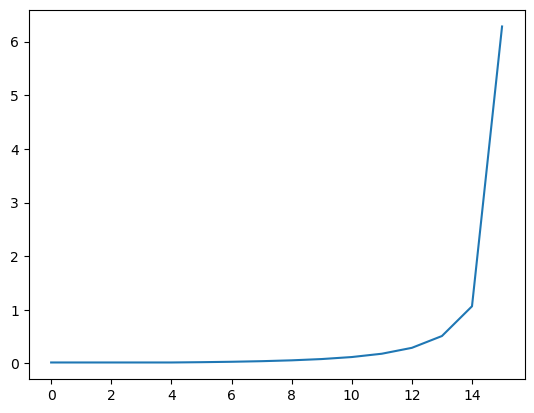

In [271]:
omega =  1 / (ang_min * (ang_max / ang_min)**(omega_pow**0.5))
plt.plot(omega)

In [278]:
def get_omega(emb_dim, emb_trunc, min_angle, max_angle, gamma=1):
    trunc_emb_dim = int(emb_dim * emb_trunc)
    omega_pow = np.concat([np.ones(trunc_emb_dim), np.linspace(1, 0, emb_dim - trunc_emb_dim)])
    omega = 1 / (min_angle * (max_angle / min_angle)**(omega_pow**gamma))
    return omega

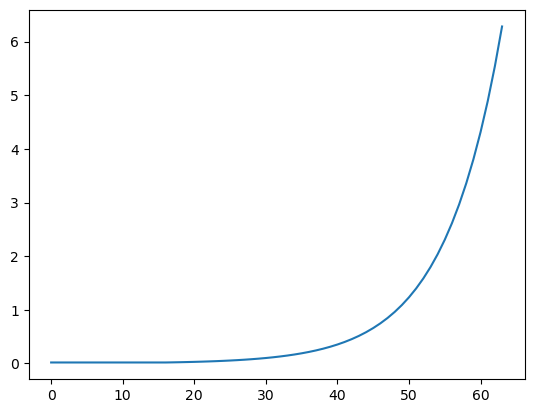

In [290]:
plt.plot(get_omega(64, 0.25, 1  / (2*np.pi), 360 / (2*np.pi), gamma=1))

In [183]:
get_omega(16, 0.25, 1, 10000)

array([1.00000000e-04, 1.00000000e-04, 1.00000000e-04, 1.00000000e-04,
       1.00000000e-04, 2.31012970e-04, 5.33669923e-04, 1.23284674e-03,
       2.84803587e-03, 6.57933225e-03, 1.51991108e-02, 3.51119173e-02,
       8.11130831e-02, 1.87381742e-01, 4.32876128e-01, 1.00000000e+00])

In [187]:
get_omega(16, 0.25, (1/(24*60)) / (2*np.pi), 1 / (2*np.pi))

array([6.28318531e+00, 6.28318531e+00, 6.28318531e+00, 6.28318531e+00,
       6.28318531e+00, 1.21703686e+01, 2.35736914e+01, 4.56616349e+01,
       8.84454142e+01, 1.71316496e+02, 3.31835653e+02, 6.42757139e+02,
       1.24500407e+03, 2.41154091e+03, 4.67109282e+03, 9.04778684e+03])

In [265]:
limits = [
    [1  / (2*np.pi), 360 / (2*np.pi)], # longitude 1->360 degrees
    [1  / (2*np.pi), 360 / (2*np.pi)], # latitude 1->360 degrees
    [(1/(24*60)) / (2*np.pi), 1 / (2*np.pi)], # time of day 1 minute -> 1 day
    [1, 10000], # epoch 2 pi days -> 20000 pi days (~80 years)
]

In [266]:
omegas = [get_omega(emb_dim // (num_coords * encoder_heads * 2), emb_trunc, *ang) for ang in limits]

In [267]:
omegas

[array([0.01745329, 0.01745329, 0.01745329, 0.01745329, 0.01745329,
        0.02980358, 0.05089319, 0.0869062 , 0.14840274, 0.25341543,
        0.43273716, 0.73895046, 1.2618463 , 2.1547535 , 3.67949936,
        6.28318531]),
 array([0.01745329, 0.01745329, 0.01745329, 0.01745329, 0.01745329,
        0.02980358, 0.05089319, 0.0869062 , 0.14840274, 0.25341543,
        0.43273716, 0.73895046, 1.2618463 , 2.1547535 , 3.67949936,
        6.28318531]),
 array([6.28318531e+00, 6.28318531e+00, 6.28318531e+00, 6.28318531e+00,
        6.28318531e+00, 1.21703686e+01, 2.35736914e+01, 4.56616349e+01,
        8.84454142e+01, 1.71316496e+02, 3.31835653e+02, 6.42757139e+02,
        1.24500407e+03, 2.41154091e+03, 4.67109282e+03, 9.04778684e+03]),
 array([1.00000000e-04, 1.00000000e-04, 1.00000000e-04, 1.00000000e-04,
        1.00000000e-04, 2.31012970e-04, 5.33669923e-04, 1.23284674e-03,
        2.84803587e-03, 6.57933225e-03, 1.51991108e-02, 3.51119173e-02,
        8.11130831e-02, 1.87381742e-01, 4.

In [222]:
angles = torch.cat(
    [
        torch.einsum('bm,d->bmd', coords[:,i], torch.tensor(o, dtype=coords.dtype, device=coords.device)) for i, o in enumerate(omegas)
    ], 
    -1
)

In [223]:
angles.shape

torch.Size([1, 256, 64])

In [224]:
1024 / 8 / 2

64.0

In [225]:
torch.sin(angles)

tensor([[[-0.0636, -0.0636, -0.0636,  ...,  0.0004,  0.0008,  0.0020],
         [-0.0569, -0.0569, -0.0569,  ...,  0.0004,  0.0008,  0.0020],
         [-0.0502, -0.0502, -0.0502,  ...,  0.0004,  0.0008,  0.0020],
         ...,
         [ 0.0547,  0.0547,  0.0547,  ...,  0.0004,  0.0008,  0.0020],
         [ 0.0626,  0.0626,  0.0626,  ...,  0.0004,  0.0008,  0.0020],
         [ 0.0705,  0.0705,  0.0705,  ...,  0.0004,  0.0008,  0.0020]]])

In [226]:
torch.cos(angles)

tensor([[[0.9980, 0.9980, 0.9980,  ..., 1.0000, 1.0000, 1.0000],
         [0.9984, 0.9984, 0.9984,  ..., 1.0000, 1.0000, 1.0000],
         [0.9987, 0.9987, 0.9987,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [0.9985, 0.9985, 0.9985,  ..., 1.0000, 1.0000, 1.0000],
         [0.9980, 0.9980, 0.9980,  ..., 1.0000, 1.0000, 1.0000],
         [0.9975, 0.9975, 0.9975,  ..., 1.0000, 1.0000, 1.0000]]])

In [229]:
rotations = torch.polar(torch.ones_like(angles), angles)

In [230]:
rotations.shape

torch.Size([1, 256, 64])

In [202]:
coords.shape

torch.Size([1, 4, 256])

In [211]:
image.shape

torch.Size([1, 3, 256, 256])

In [231]:
patch_embed = nn.Conv2d(3, 128, 16, 16)

In [250]:
x = patch_embed(image).reshape(1,128,-1).permute(0,2,1).contiguous()

In [251]:
x.shape

torch.Size([1, 256, 128])

In [252]:
x.stride()

(32768, 128, 1)

In [258]:
pe_x = rotations * torch.view_as_complex(x.reshape(*x.shape[:-1], -1, 2))

In [259]:
pe_x.shape

torch.Size([1, 256, 64])

In [264]:
torch.view_as_real(pe_x).reshape(x.shape)

tensor([[[-0.7951, -0.1410, -0.7675,  ...,  0.6800,  0.7372, -0.1896],
         [-0.8126, -0.1545, -0.7299,  ...,  0.5934,  0.7425, -0.2142],
         [-0.8187, -0.1090, -0.7404,  ...,  0.6806,  0.7268, -0.1734],
         ...,
         [-0.6968, -0.2162, -0.6219,  ...,  0.5410,  0.6665, -0.1667],
         [-0.6105, -0.2800, -0.5564,  ...,  0.5035,  0.5861, -0.1309],
         [-0.6254, -0.1437, -0.6501,  ...,  0.4418,  0.5973, -0.1429]]],
       grad_fn=<ViewBackward0>)

In [359]:
class Geo_RoPE(torch.nn.Module):
    """Geospatial Rotary Positional Embedding

    based on https://github.com/limefax/rope-nd
    """
    def __init__(
        self, 
        emb_dim: int,
        num_coords: int, 
        limits: list[list[float]], 
        trunc_embed: float = 0., 
        gamma: float = 1., 
    ) -> Geo_RoPE:
        super().__init__()

        assert (emb_dim % (2*num_coords)) == 0, f'Embedding dim must divide by 2 * number of coordinates ({2*num_coords})'
        self.emb_dim = emb_dim // (2*num_coords)
        self.num_coords = num_coords
        assert len(limits) == num_coords, f'Length of limits much match num_coords ({num_coords})'
        self.limits = limits
        self.trunc_embed = trunc_embed
        self.gamma = gamma

    def get_omega(self, min_angle:float, max_angle:float) -> np.ndarray:
        """Get omega values to produce series of angles
        """
        trunc_emb_dim = int(self.emb_dim * self.trunc_embed)
        omega_pow = np.concat([np.ones(trunc_emb_dim), np.linspace(1, 0, self.emb_dim - trunc_emb_dim)])
        omega = 1 / (min_angle * (max_angle / min_angle)**(omega_pow**self.gamma))
        return omega

    def update(self, coords: torch.tensor) -> None:
        """Update angles with new set of coordinates

        should be performed at the start of each batch
        """
        assert coords.shape[1] == self.num_coords
        omegas = [
            self.get_omega(*limit) for limit in self.limits
        ]
        angles = torch.cat(
            [
                torch.einsum(
                    'bm,d->bmd', 
                    coords[:,i], 
                    torch.tensor(o, dtype=coords.dtype, device=coords.device)
                ) for i, o in enumerate(omegas)
            ], 
            -1
        )
        self.rotations = torch.polar(torch.ones_like(angles), angles)

    def forward(self, x: torch.tensor) -> torch.tensor:
        pe_x = self.rotations * torch.view_as_complex(x.reshape(*x.shape[:-1], -1, 2).contiguous())
        return torch.view_as_real(pe_x).reshape(x.shape)

In [364]:
pos_encoder = Geo_RoPE(128, 4, limit_angles, trunc_embed=0.25, gamma=0.5)

In [365]:
pos_encoder.update(coords)

In [366]:
pos_encoder.rotations.shape

torch.Size([1, 256, 64])

In [367]:
pos_encoder(x)

tensor([[[-0.7951, -0.1410, -0.7675,  ...,  0.6803,  0.7372, -0.1896],
         [-0.8126, -0.1545, -0.7299,  ...,  0.5936,  0.7425, -0.2142],
         [-0.8187, -0.1090, -0.7404,  ...,  0.6809,  0.7268, -0.1734],
         ...,
         [-0.6968, -0.2162, -0.6219,  ...,  0.5412,  0.6665, -0.1667],
         [-0.6105, -0.2800, -0.5564,  ...,  0.5036,  0.5861, -0.1309],
         [-0.6254, -0.1437, -0.6501,  ...,  0.4420,  0.5973, -0.1429]]],
       grad_fn=<ViewBackward0>)

In [368]:
x.shape

torch.Size([1, 256, 128])

In [369]:
x_rand = torch.rand(2, 8, 256, 128)

In [371]:
pos_encoder(x_rand).shape

torch.Size([2, 8, 256, 128])